# M4 - DLinear-vol : Deep Learning Lineaire vs HAR (previsions pures)

**Evaluation en prevision pure (MSE + Diebold-Mariano)** -- un angle distinct de M12 et M15, qui
evaluaient la **strategie** (Sharpe via Kelly). Ici, pas de Kelly : on demande simplement si le DL
lineaire prevoit la variance realisee *mieux* que le HAR classique.

DLinear (Zeng et al. AAAI 2023) est un resultat surprenant : une simple couche `nn.Linear` egale ou
bat les Transformers complexes sur les benchmarks long-terme. Ce notebook teste si cette linearite
suffit a capturer les dynamiques de volatilite crypto que les caracteristiques HAR (moyennes 1j/5j/22j)
manquent -- et annonce l'echec du Transformer complexe (M9 TFT, cf [`docs/M9_TFT_VOL.md`](docs/M9_TFT_VOL.md)).

**Modele** (Zeng et al. 2023, adapte) :
```
y_hat = Linear(seq_len=22 -> horizon)
```
Entree : 22 dernieres valeurs quotidiennes de log-RV (normalisees)
Sortie : horizon prochain log-RV (h in {1, 5, 10})
~22 parametres (vs ~4.8K pour le LSTM M15, ~110K pour le TFT M9).

**Verdict** : 5/21 BEATS -- DLinear bat HAR en MSE sur **BTC a tous les horizons** (15-38% de
reduction, p < 1e-9) plus ETH/SOL a h=1. Les autres coins restent INCONCLUSIVE (trop peu de donnees).

> **Fiche technique complete** : [`docs/M4_DLINEAR_VOL.md`](docs/M4_DLINEAR_VOL.md). **Script** :
> `scripts/` (DLinear walk-forward). **Resultats** : Cycle 25 Wave 3, 84 combos (7 coins x 3 horizons x 4 seeds).

## 1. Chargement des resultats

Resultats pre-calcules (84 combos : 7 coins x 3 horizons x 4 seeds). Setup : seq_len=22,
walk-forward 5-fold, refit 22 jours, 100 epochs. La metrique est le **MSE sur log-RV** compare
via le test de Diebold-Mariano (HAC Newey-West), pas le Sharpe.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_path = Path('scripts/results/m4_dlinear_vol_full.json')
with open(results_path) as f:
    data = json.load(f)

rows = pd.DataFrame(data['rows'])
agg = pd.DataFrame(data['aggregated'])

print(f'Model: DLinear-vol (Linear seq_len=22 -> horizon, ~22 params)')
print(f'Reference: Zeng et al. (2023), Are Transformers Effective for Time Series Forecasting? AAAI')
print(f'Rows brutes : {len(rows)} combos ({rows["coin"].nunique()} coins x {rows["horizon"].nunique()} horizons x {rows["seed"].nunique()} seeds)')
print(f'Configs agregees : {len(agg)} (coin x horizon, moyenne sur 4 seeds)')
print(f'Runtime original : {data["elapsed_s"]:.0f}s ({data["elapsed_s"]/3600:.1f}h)')
print(f'Setup : seq_len={data["config"]["seq_len"]}, WF {data["config"]["n_splits"]}-fold, refit={data["config"]["refit_every"]}d, {data["config"]["epochs"]} epochs')
print(f'Metrique : MSE sur log-RV + test Diebold-Mariano (HAC) -- PAS de Kelly/Sharpe ici')

Model: DLinear-vol (Linear seq_len=22 -> horizon, ~22 params)
Reference: Zeng et al. (2023), Are Transformers Effective for Time Series Forecasting? AAAI
Rows brutes : 84 combos (7 coins x 3 horizons x 4 seeds)
Configs agregees : 21 (coin x horizon, moyenne sur 4 seeds)
Runtime original : 9082s (2.5h)
Setup : seq_len=22, WF 5-fold, refit=22d, 100 epochs
Metrique : MSE sur log-RV + test Diebold-Mariano (HAC) -- PAS de Kelly/Sharpe ici


## 2. Verdict global : succes BTC-dominant

DLinear bat HAR en MSE sur **5/21 configurations**, toutes concentrees sur **BTC** (3/3 horizons)
plus ETH et SOL a h=1. La reduction MSE sur BTC est importante (15-38%) et tres significative
(p < 1e-9). Les autres coins montrent une reduction numerique moyenne mais non significative.

In [2]:
verdict_counts = agg['verdict'].value_counts()
n_beats = int((agg['verdict']=='BEATS').sum())
n_inc = int((agg['verdict']=='INCONCLUSIVE').sum())
print('=== Verdict global DLinear vs HAR (previsions MSE) ===')
print()
print(f'BEATS         : {n_beats}/21')
print(f'INCONCLUSIVE  : {n_inc}/21')
print(f'NO BEATS      : 0/21  (DLinear ne fait jamais significativement pire que HAR)')
print(f'Reduction MSE moyenne (toutes configs) : {agg["mean_reduction_pct"].mean():+.1f}%')
print()
print('Configurations BEATS (detail) :')
beats = agg[agg['verdict']=='BEATS'].sort_values('mean_reduction_pct', ascending=False)
for _, r in beats.iterrows():
    print(f'  {r["coin"]:8s} h={int(r["horizon"]):2d} : reduction MSE {r["mean_reduction_pct"]:+.1f}%, p={r["mean_dm_pvalue"]:.2e}')

=== Verdict global DLinear vs HAR (previsions MSE) ===

BEATS         : 5/21
INCONCLUSIVE  : 16/21
NO BEATS      : 0/21  (DLinear ne fait jamais significativement pire que HAR)
Reduction MSE moyenne (toutes configs) : +7.6%

Configurations BEATS (detail) :
  BTC-USD  h=10 : reduction MSE +38.3%, p=2.45e-09
  BTC-USD  h= 5 : reduction MSE +28.3%, p=2.29e-10
  BTC-USD  h= 1 : reduction MSE +15.3%, p=0.00e+00
  SOL-USD  h= 1 : reduction MSE +9.8%, p=1.00e-03
  ETH-USD  h= 1 : reduction MSE +3.3%, p=3.60e-02


## 3. Le facteur decisif : la longueur des donnees

Pourquoi seulement BTC ? Parce que BTC a **2278 jours** de donnees RV (~10 ans, Bitstamp hourly),
tandis que les autres coins n'en ont que ~725 (~2 ans, yfinance). DLinear (comme tout modele DL)
a besoin de donnees pour apprendre la map lineaire ; sur 2 ans, l'edge est noye dans le bruit.
C'est la meme histoire que le HAR asymetrique (M3b, BTC-only) : la longueur de donnees est le
facteur limitant sur ce benchmark crypto.

=== Reduction MSE par coin (moyenne sur 3 horizons) ===

Coin       BEATS    MSE red moy  Jours RV
ADA-USD    0/3       +4.6%       725
BTC-USD    3/3      +27.3%       2278  <- BEATS
DOT-USD    0/3       +0.9%       725
ETH-USD    1/3       +4.4%       1495  <- BEATS
LTC-USD    0/3       +7.5%       725
SOL-USD    1/3       +5.5%       725  <- BEATS
XRP-USD    0/3       +2.8%       725


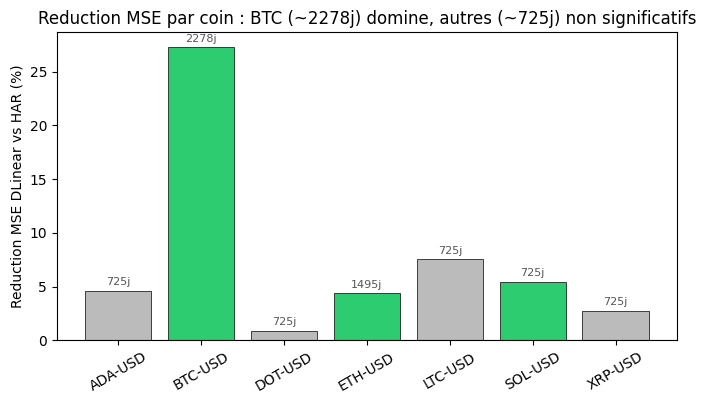

Vert = au moins 1 config BEATS (BTC, ETH, SOL). Gris = INCONCLUSIVE. Etiquette = jours RV.


In [3]:
print('=== Reduction MSE par coin (moyenne sur 3 horizons) ===')
print()
print(f'{"Coin":<10} {"BEATS":<8} {"MSE red moy":<12} {"Jours RV"}')
coin_days = rows.groupby('coin')['n_rv_days'].first()
for coin in sorted(agg['coin'].unique()):
    sub = agg[agg['coin']==coin]
    beats = int((sub['verdict']=='BEATS').sum())
    red = sub['mean_reduction_pct'].mean()
    days = int(coin_days.get(coin, 0))
    flag = '  <- BEATS' if beats > 0 else ''
    print(f'{coin:<10} {beats}/3     {red:+6.1f}%       {days}{flag}')

fig, ax = plt.subplots(figsize=(8, 4))
coins = sorted(agg['coin'].unique())
mean_reds = [agg[agg['coin']==c]['mean_reduction_pct'].mean() for c in coins]
days = [int(coin_days.get(c, 0)) for c in coins]
colors = ['#2ecc71' if (agg[agg['coin']==c]['verdict']=='BEATS').any() else '#bbbbbb' for c in coins]
bars = ax.bar(coins, mean_reds, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Reduction MSE DLinear vs HAR (%)')
ax.set_title('Reduction MSE par coin : BTC (~2278j) domine, autres (~725j) non significatifs')
ax.tick_params(axis='x', rotation=30)
for b, c, d in zip(bars, coins, days):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{d}j', ha='center', fontsize=8, color='#555')
plt.show()
print('Vert = au moins 1 config BEATS (BTC, ETH, SOL). Gris = INCONCLUSIVE. Etiquette = jours RV.')

## 4. Analyse par horizon

L'edge est le plus marque a **h=1** (3/7 BEATS : BTC, ETH, SOL), ou la map lineaire court-terme
capture les dynamiques recentes. Aux horizons longs (h=5, h=10), seul BTC reste BEATS -- la
prevision long-terme est plus dure et exige plus de donnees.

=== Performance par horizon ===

Horizon    BEATS      MSE red moy 


h=1        3/7       +5.9%
h=5        1/7       +8.4%
h=10       1/7       +8.5%


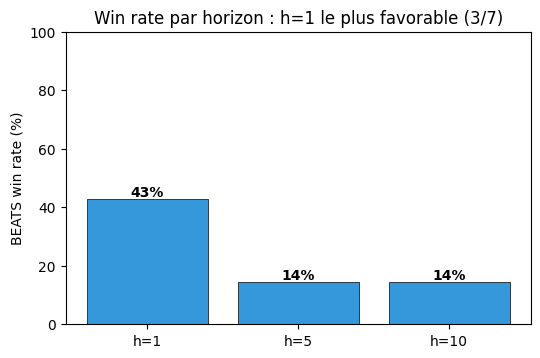

In [4]:
print('=== Performance par horizon ===')
print()
print(f'{"Horizon":<10} {"BEATS":<10} {"MSE red moy":<12}')
for h in [1, 5, 10]:
    sub = agg[agg['horizon']==h]
    beats = int((sub['verdict']=='BEATS').sum())
    red = sub['mean_reduction_pct'].mean()
    print(f'h={h:<8} {beats}/7       {red:+.1f}%')

fig, ax = plt.subplots(figsize=(6, 3.8))
horizons = [1, 5, 10]
winrates = [(agg[(agg['horizon']==h)]['verdict']=='BEATS').sum()/7*100 for h in horizons]
bars = ax.bar([f'h={h}' for h in horizons], winrates, color='#3498db', edgecolor='k', linewidth=0.5)
ax.set_ylabel('BEATS win rate (%)')
ax.set_title('Win rate par horizon : h=1 le plus favorable (3/7)')
ax.set_ylim(0, 100)
for b, w in zip(bars, winrates):
    ax.text(b.get_x()+b.get_width()/2, w+1, f'{w:.0f}%', ha='center', fontsize=10, fontweight='bold')
plt.show()

## 5. La suite : pourquoi DLinear a mene au TFT (et a l'echec M9)

M4 a montre qu'un DL **lineaire** simple (22 params) bat HAR sur BTC. La question naturelle :
une architecture **plus expressive** peut-elle faire mieux ? Cela a mene a M9, le Temporal Fusion
Transformer (~110K params, LSTM + multi-head attention + variable selection).

**Reponse de M9** : non, catastrophiquement. Le TFT a **0/6 BEATS** avec une DirAcc de 0.4993
(essentiellement aleatoire, en dessous de la baseline majority-class). Le surparametrage tue
la generalisation sur des donnees crypto limitees.

### La courbe d'expressivite (synthese du pipeline vol)

| Modele | Params | Angle | Verdict | Notebook |
|--------|--------|-------|---------|----------|
| M12 HAR-RV-J (OLS) | 7 | strategie (Sharpe) | BEATS, **deploye** | [m12](m12_har_rv_j_research.ipynb) |
| M4 DLinear | ~22 | prevision (MSE) | 5/21 BEATS (BTC) | ce notebook |
| M15 Log-LSTM h=32 | 4 769 | strategie (Sharpe) | BEATS, keeper **non deploye** | [m15](m15_lstm_rv_research.ipynb) |
| M9 TFT | ~110K | prevision (DirAcc) | 0/6 BEATS (overfit) | (doc [`M9`](docs/M9_TFT_VOL.md) seul) |

La leçon : sur ce benchmark crypto, l'expressivite est **anti-correlee au succes**. Le modele OLS
(M12) part le plus loin en production ; le DL lineaire (M4) reussit localement en prevision ; le
LSTM (M15) reussit en strategie mais reste non deploye (barriere Torch) ; le Transformer (M9)
echoue par surparametrage. **Simplicite gagne** -- un fil conducteur de tout le pipeline vol.

### References

- Zeng, A., Chen, M., Zhang, L. & Xu, Q. (2023). *Are Transformers Effective for Time Series
  Forecasting?* AAAI 2023. (DLinear, le papier fondateur).
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. (HAR baseline).
- Diebold, F.X. & Mariano, R.S. (1995). *Comparing Predictive Accuracy*. JBES. (test DM).
- Pour la suite Transformer (echec) : [`docs/M9_TFT_VOL.md`](docs/M9_TFT_VOL.md).
- Pour les pendants strategie : [M12 HAR-RV-J](m12_har_rv_j_research.ipynb), [M15 Log-LSTM](m15_lstm_rv_research.ipynb).